# Documentação do Programa de Análise de Regressão
### Introdução
#### Este programa foi desenvolvido para facilitar a análise de regressão de dados de entrada em formato CSV. Ele permite carregar dados de um arquivo CSV, calcular a linha de regressão e plotar um gráfico para visualizar os dados originais juntamente com a linha de regressão.

-------MAIN MENU---------
Select an option:
1 --- Introduce File Name
2 --- Show Polynomial Regression
0 --- Exit
Data loaded successfully.
-------MAIN MENU---------
Select an option:
1 --- Introduce File Name
2 --- Show Polynomial Regression
0 --- Exit
#################################################################
The regression line is y = -438.092 + 0.463x


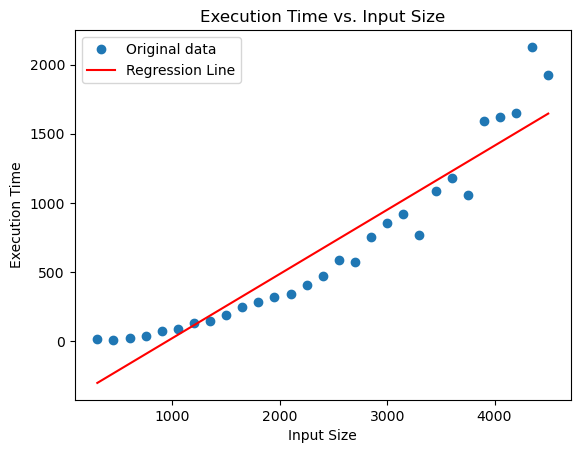

-------MAIN MENU---------
Select an option:
1 --- Introduce File Name
2 --- Show Polynomial Regression
0 --- Exit
Exiting...


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

# Variáveis globais para armazenar os tempos de execução e os tamanhos de entrada
execution_times = []
input_sizes = []

def read_from_file():
    """
    Função para ler os dados de um arquivo CSV.

    Solicita ao usuário o nome do arquivo CSV contendo os dados de entrada.
    Os dados são lidos do arquivo usando o Pandas e armazenados nas variáveis globais execution_times e input_sizes.
    """
    global execution_times, input_sizes
    filename = input("Enter the data file name with the data (.csv): ")
    try:
        # Leitura dos dados do arquivo CSV usando o Pandas
        data = pd.read_csv(filename, delimiter=";")
        # Conversão dos dados para o tipo float e armazenamento nas variáveis globais
        input_sizes = data.iloc[:, 0].astype(str).str.replace(',', '.').astype(float).tolist()
        execution_times = data.iloc[:, 1].astype(str).str.replace(',', '.').astype(float).tolist()
        print("Data loaded successfully.")
    except FileNotFoundError:
        print("File not found. Please check the filename and try again.")
    except Exception as e:
        print(f"An error occurred: {e}")

def calculate_regression_line():
    """
    Função para calcular a linha de regressão.

    Calcula a linha de regressão dos dados de entrada usando a função linregress do módulo stats do Scipy.
    """
    global model
    # Calcula a linha de regressão usando os dados de entrada e de execução
    model = stats.linregress(input_sizes, execution_times)
    # Chama a função para plotar o gráfico
    plot_graph()

def plot_graph():
    """
    Função para plotar o gráfico dos dados originais e da linha de regressão.

    Plota um gráfico dos dados originais (tamanhos de entrada versus tempos de execução) e da linha de regressão calculada.
    """
    print('#################################################################')
    # Imprime a equação da linha de regressão
    print(f'The regression line is y = {model.intercept:.3f} + {model.slope:.3f}x')
    # Plota o gráfico dos dados originais como pontos
    plt.plot(input_sizes, execution_times, 'o', label='Original data')
    # Plota a linha de regressão
    plt.plot(input_sizes, model.intercept + model.slope * pd.Series(input_sizes), 'r', label='Regression Line')
    # Adiciona legendas aos eixos e ao gráfico
    plt.legend()
    plt.xlabel('Input Size')
    plt.ylabel('Execution Time')
    plt.title('Execution Time vs. Input Size')
    # Exibe o gráfico
    plt.show()

# Loop principal do programa
option = -1
while option != 0:
    print("-------MAIN MENU---------")
    print("Select an option:")
    print("1 --- Introduce File Name")
    print("2 --- Show Polynomial Regression")
    print("0 --- Exit")
    try:
        option = int(input("opt: "))
        if option == 1:
            read_from_file()  # Chama a função para ler os dados do arquivo CSV
        elif option == 2:
            if input_sizes and execution_times:
                calculate_regression_line()  # Chama a função para calcular a linha de regressão
            else:
                print("Please load data first by selecting option 1.")
        elif option == 0:
            print("Exiting...")
        else:
            print("Invalid option. Please select a valid option.")
    except ValueError:
        print("Invalid input. Please enter a number.")
